Columns: Index(['person_id', 'age', 'gender', 'height_cm', 'weight_kg', 'steps_per_day',
       'calories_burned', 'sleep_hours'],
      dtype='object')
   person_id  age  gender  height_cm  weight_kg  steps_per_day  \
0          1   25    Male        175       70.0           8000   
1          2   30  Female        160       60.0           6000   
2          3   22    Male        180       80.0          10000   
3          4   28  Female        165       55.0           5000   
4          5   35    Male        170       85.0           7000   

   calories_burned  sleep_hours  
0             2200            7  
1             1800            6  
2             2500            8  
3             1600            5  
4             2300            6  


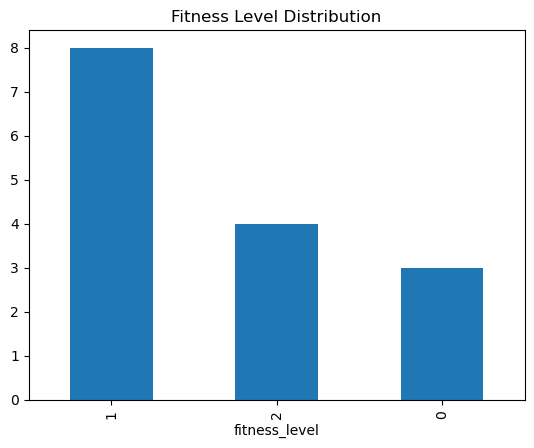

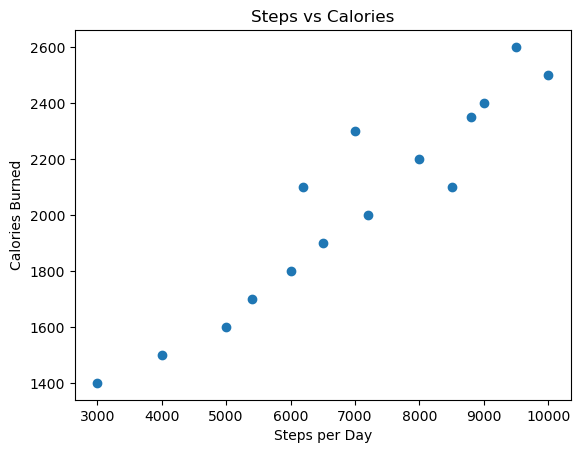

Accuracy: 0.6666666666666666


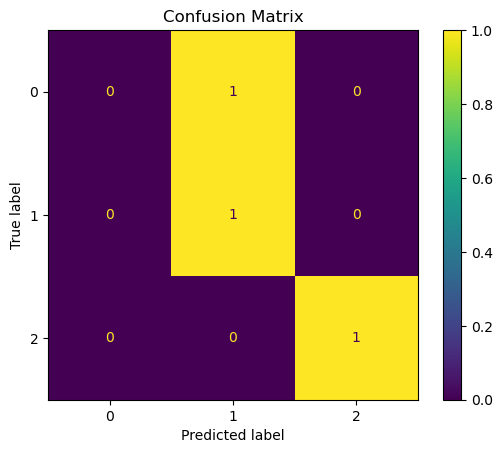

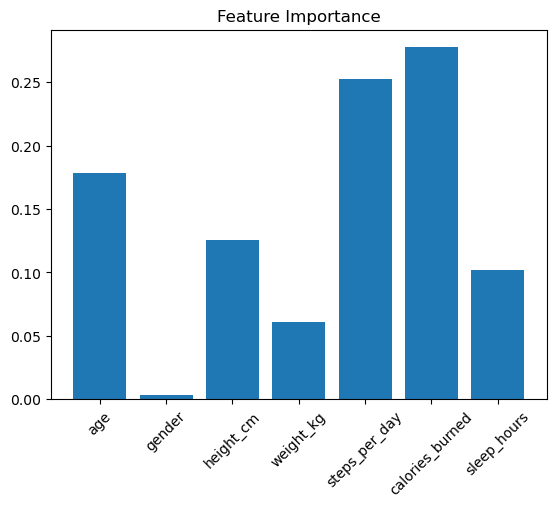

Project Completed Successfully


In [2]:
# FITNESS PROJECT (FIXED FOR YOUR DATASET)


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("dataset1.csv")

df.columns = df.columns.str.strip()

print("Columns:", df.columns)
print(df.head())

df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].mean())

def fitness_label(row):
    if row['steps_per_day'] > 8000 and row['calories_burned'] > 2200:
        return 2   # Fit
    elif row['steps_per_day'] > 5000:
        return 1  
    else:
        return 0   

df['fitness_level'] = df.apply(fitness_label, axis=1)

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

df['fitness_level'].value_counts().plot(kind='bar')
plt.title("Fitness Level Distribution")
plt.show()

plt.scatter(df['steps_per_day'], df['calories_burned'])
plt.xlabel("Steps per Day")
plt.ylabel("Calories Burned")
plt.title("Steps vs Calories")
plt.show()

X = df[['age', 'gender', 'height_cm', 'weight_kg', 'steps_per_day', 'calories_burned', 'sleep_hours']]
y = df['fitness_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

print("Project Completed Successfully")